# Phase 2 — Online RLS Estimator

**Goal:** Run the RLS estimator sample-by-sample on A1-007 data. Watch R₀/R₁/C₁ evolve over time.
Confirm rolling RMSE beats the Phase 1 static baseline of **484.72 mV**.

### How RLS works here
At each sample k the ECM voltage equation is rearranged into a linear regression:
```
y[k]   = V_t[k] - V_oc[k] + α·(V_oc[k-1] - V_t[k-1])
phi[k] = [-I[k],  I[k-1]]
theta  = [a, b]    where  a = R0,  b = α·R0 - R1·(1-α)
```
The RLS update adjusts theta to minimise the weighted sum of squared errors,
with recent samples weighted more heavily via the forgetting factor λ.

**Phase 1 baseline RMSE: 484.72 mV — beat this.**

## 1. Imports & setup

In [1]:
import sys
import numpy as np
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Add the online-ecm folder to path so we can import rls.py
sys.path.insert(0, r'C:\Users\Vcpat\Downloads\online-ecm')
from rls import RLS

plt.rcParams.update({
    'figure.figsize': (13, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.0,
})

PHASE1_RMSE_MV = 484.72   # baseline to beat
Q_NOM_AH = 1.35

print('Imports OK')
print(f'Phase 1 baseline: {PHASE1_RMSE_MV} mV')

Imports OK
Phase 1 baseline: 484.72 mV


## 2. Load data from battdb

In [2]:
conn = psycopg2.connect(
    host='localhost', port=5454,
    dbname='battdb', user='postgres', password='password'
)

query = """
    SELECT
        td.test_time_s,
        td.current_ma  / 1000.0  AS current_a,
        td.voltage_mv  / 1000.0  AS voltage_v,
        td.step,
        td.cycle
    FROM test_data td
    JOIN test_meta tm ON td.test_id = tm.test_id
    WHERE tm.test_name = 'CALCE_A1-007_OCV_neg10C_20120629'
    ORDER BY td.test_time_s
"""

df = pd.read_sql(query, conn)
conn.close()

# Compute dt and SOC
dt_arr = np.diff(df['test_time_s'].values, prepend=df['test_time_s'].iloc[0])
dt_arr = np.clip(dt_arr, 0.1, 60.0)
dt_arr[0] = dt_arr[1]

charge_ah = np.cumsum(df['current_a'].values * dt_arr) / 3600
df['soc'] = np.clip(1.0 + charge_ah / Q_NOM_AH, 0, 1)
df['dt']  = dt_arr

# OCV curve from Phase 1
soc_ocv = np.array([0.0,   0.217,  0.954,  1.0])
v_ocv   = np.array([2.208, 2.506,  3.402,  3.548])
ocv_fn  = interp1d(soc_ocv, v_ocv, kind='linear', fill_value='extrapolate')

df['v_oc'] = ocv_fn(df['soc'].values)

print(f'Loaded {len(df):,} samples')
df.head()

C:\Users\Vcpat\AppData\Local\Temp\ipykernel_38884\4023449191.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Loaded 59,570 samples


,test_time_s,current_a,voltage_v,step,cycle,soc,dt,v_oc
0,3.011,0.000000,3.480732,1,1,1.0,0.100,3.548
1,3.011,0.000000,3.480732,1,1,1.0,0.100,3.548
2,3.027,1.151195,3.917767,2,1,1.0,0.100,3.548
3,3.027,1.151195,3.917767,2,1,1.0,0.100,3.548
4,8.036,0.205528,3.601070,3,1,1.0,5.009,3.548


## 3. Run RLS sample by sample

Tune λ here. Start with 0.995 then try 0.98 and 0.999 to see the effect.

In [3]:
# ── Tunable parameters ────────────────────────────────────────────────
LAMBDA     = 0.995   # forgetting factor — try 0.98, 0.995, 0.999
ALPHA      = 0.97    # exp(-dt/tau), fixed — tau ≈ 100s at dt=3s
DT_NOM     = 3.0     # nominal timestep (s)
# ─────────────────────────────────────────────────────────────────────

estimator = RLS(
    lam=LAMBDA,
    alpha=ALPHA,
    dt=DT_NOM,
    theta_init=[0.1, 0.0],
    P_init=1000.0,
)

I_arr   = df['current_a'].values
V_arr   = df['voltage_v'].values
Voc_arr = df['v_oc'].values
dt_arr  = df['dt'].values
soc_arr = df['soc'].values

# Output arrays
n = len(df)
R0_hist  = np.zeros(n)
R1_hist  = np.zeros(n)
C1_hist  = np.zeros(n)
V_pred   = np.zeros(n)
err_mv   = np.zeros(n)

# Simulate ECM forward using current RLS parameters
v_rc = 0.0

for k in range(n):
    I   = I_arr[k]
    V_t = V_arr[k]
    Voc = Voc_arr[k]
    dt  = dt_arr[k]

    # RLS update — returns current parameter estimates
    params = estimator.update(I, V_t, Voc, dt=dt)

    R0 = params['R0']
    R1 = params['R1']
    C1 = params['C1']

    # Simulate ECM with current parameters
    v_pred_k    = Voc - R0 * I - v_rc
    V_pred[k]   = v_pred_k
    err_mv[k]   = (v_pred_k - V_t) * 1000

    # Update RC voltage
    tau   = max(R1 * C1, 1.0)
    alpha = np.exp(-dt / tau)
    v_rc  = v_rc * alpha + R1 * (1 - alpha) * I

    R0_hist[k] = R0
    R1_hist[k] = R1
    C1_hist[k] = C1

rmse_mv = np.sqrt(np.mean(err_mv**2))
mae_mv  = np.mean(np.abs(err_mv))

print(f'λ = {LAMBDA}  α = {ALPHA}')
print(f'Online RMSE: {rmse_mv:.2f} mV   (baseline: {PHASE1_RMSE_MV} mV)')
print(f'Online MAE:  {mae_mv:.2f} mV')
print(f'Improvement: {PHASE1_RMSE_MV - rmse_mv:+.2f} mV')

if rmse_mv < PHASE1_RMSE_MV:
    print('✓ Phase 2 beats Phase 1 baseline')
else:
    print('✗ Not yet beating baseline — try adjusting λ or α')

λ = 0.995  α = 0.97
Online RMSE: 373.27 mV   (baseline: 484.72 mV)
Online MAE:  321.79 mV
Improvement: +111.45 mV
✓ Phase 2 beats Phase 1 baseline


## 4. Plot — measured vs predicted voltage

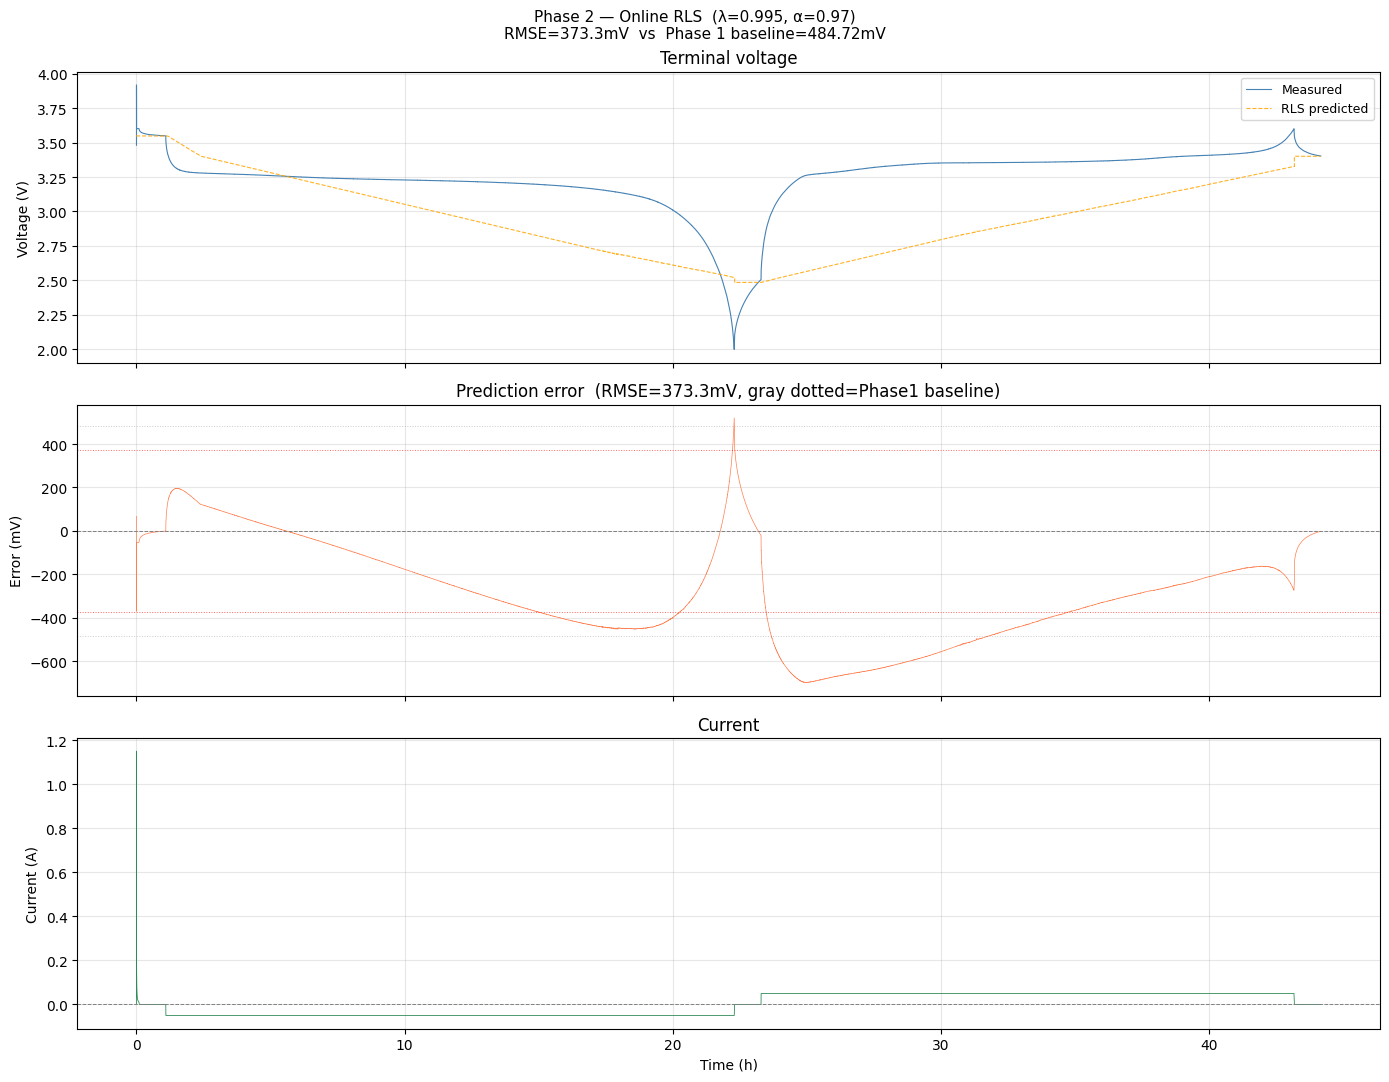

In [4]:
t = df['test_time_s'].values / 3600

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle(
    f'Phase 2 — Online RLS  (λ={LAMBDA}, α={ALPHA})\n'
    f'RMSE={rmse_mv:.1f}mV  vs  Phase 1 baseline={PHASE1_RMSE_MV}mV',
    fontsize=11
)

axes[0].plot(t, V_arr,  color='steelblue', label='Measured',       linewidth=0.8)
axes[0].plot(t, V_pred, color='orange',    label='RLS predicted',  linewidth=0.8, linestyle='--', alpha=0.85)
axes[0].set_ylabel('Voltage (V)')
axes[0].legend(fontsize=9)
axes[0].set_title('Terminal voltage')

axes[1].plot(t, err_mv, color='coral', linewidth=0.5)
axes[1].axhline(0,             color='gray', linewidth=0.7, linestyle='--')
axes[1].axhline( rmse_mv,      color='red',  linewidth=0.7, linestyle=':', alpha=0.6)
axes[1].axhline(-rmse_mv,      color='red',  linewidth=0.7, linestyle=':', alpha=0.6)
axes[1].axhline( PHASE1_RMSE_MV,  color='gray', linewidth=0.7, linestyle=':', alpha=0.4)
axes[1].axhline(-PHASE1_RMSE_MV,  color='gray', linewidth=0.7, linestyle=':', alpha=0.4)
axes[1].set_ylabel('Error (mV)')
axes[1].set_title(f'Prediction error  (RMSE={rmse_mv:.1f}mV, gray dotted=Phase1 baseline)')

axes[2].plot(t, I_arr, color='seagreen', linewidth=0.6)
axes[2].axhline(0, color='gray', linewidth=0.7, linestyle='--')
axes[2].set_ylabel('Current (A)')
axes[2].set_xlabel('Time (h)')
axes[2].set_title('Current')

plt.tight_layout()
plt.show()

## 5. Plot — parameter trajectories

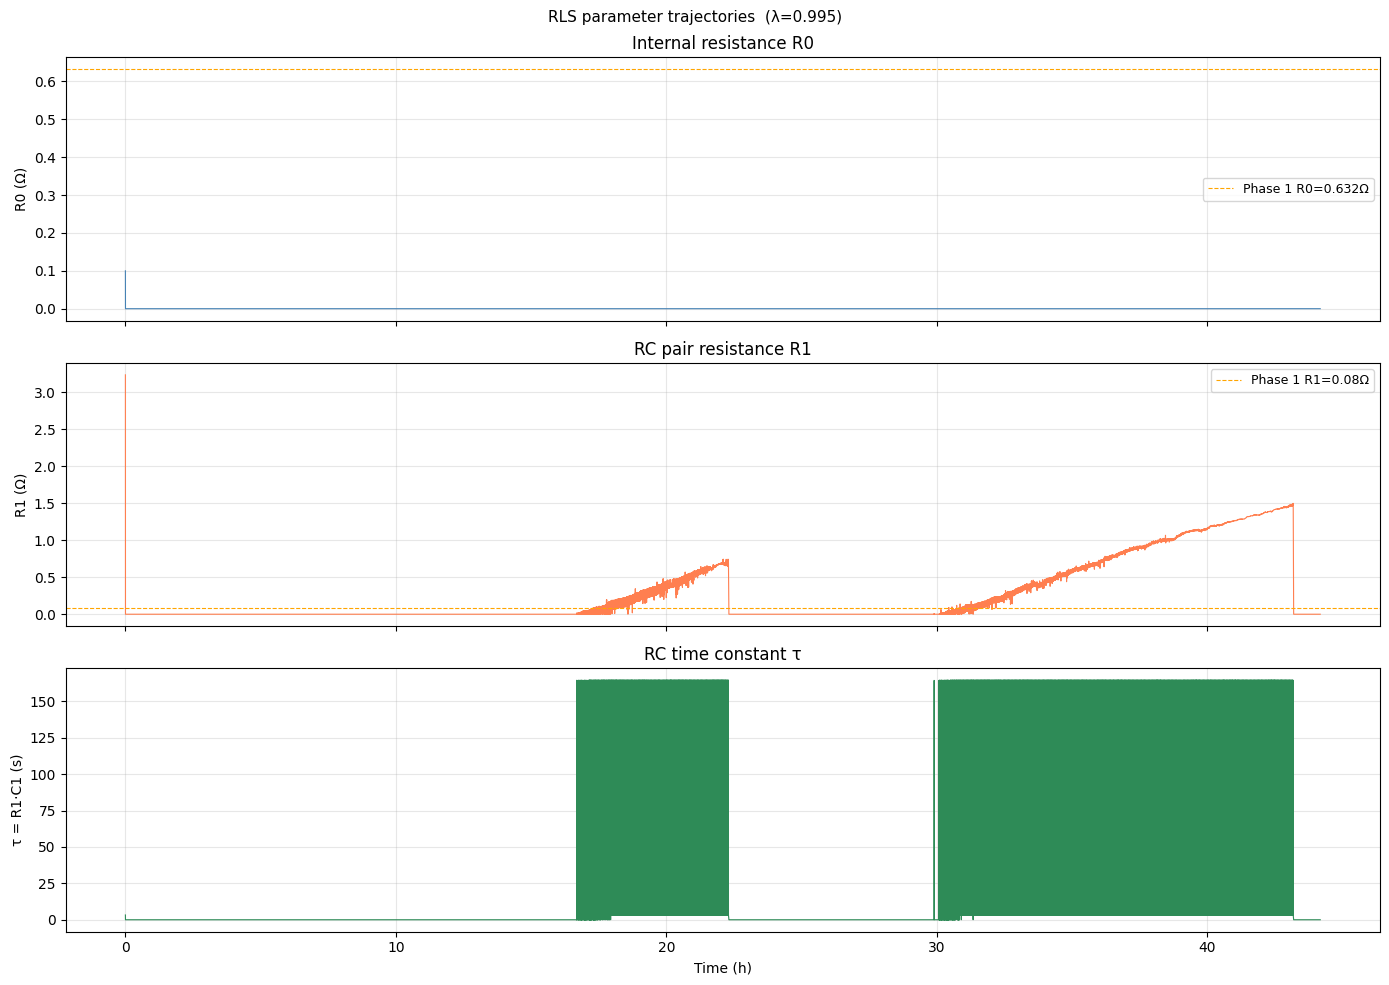

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f'RLS parameter trajectories  (λ={LAMBDA})', fontsize=11)

axes[0].plot(t, R0_hist, color='steelblue', linewidth=0.8)
axes[0].axhline(0.632, color='orange', linestyle='--', linewidth=0.8, label='Phase 1 R0=0.632Ω')
axes[0].set_ylabel('R0 (Ω)')
axes[0].set_title('Internal resistance R0')
axes[0].legend(fontsize=9)

axes[1].plot(t, R1_hist, color='coral', linewidth=0.8)
axes[1].axhline(0.080, color='orange', linestyle='--', linewidth=0.8, label='Phase 1 R1=0.08Ω')
axes[1].set_ylabel('R1 (Ω)')
axes[1].set_title('RC pair resistance R1')
axes[1].legend(fontsize=9)

axes[2].plot(t, R1_hist * C1_hist, color='seagreen', linewidth=0.8)
axes[2].set_ylabel('τ = R1·C1 (s)')
axes[2].set_xlabel('Time (h)')
axes[2].set_title('RC time constant τ')

plt.tight_layout()
plt.show()

## 6. Rolling RMSE — does online beat static over time?

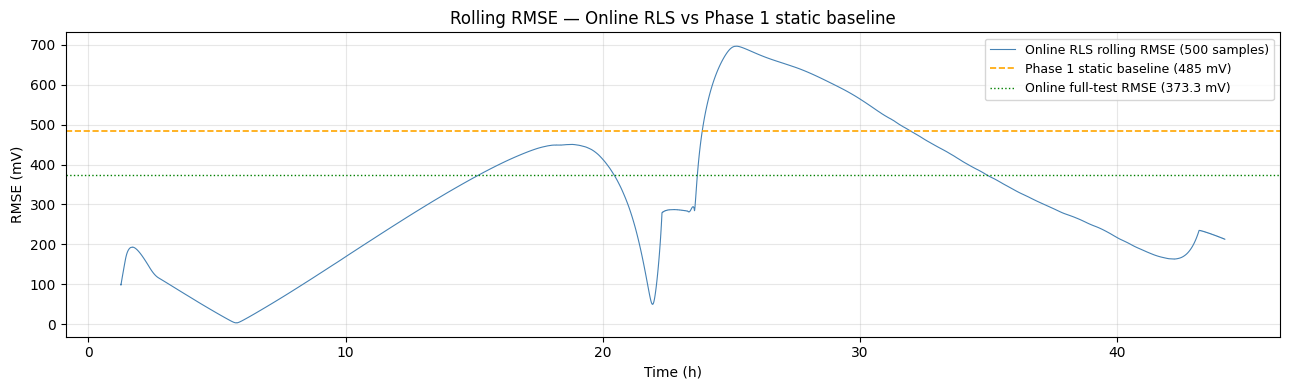

In [6]:
WINDOW = 500  # samples

rolling_rmse = pd.Series(err_mv).pow(2).rolling(WINDOW).mean().pow(0.5)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t, rolling_rmse, color='steelblue', linewidth=0.8, label=f'Online RLS rolling RMSE ({WINDOW} samples)')
ax.axhline(PHASE1_RMSE_MV, color='orange', linestyle='--', linewidth=1.2, label=f'Phase 1 static baseline ({PHASE1_RMSE_MV:.0f} mV)')
ax.axhline(rmse_mv,         color='green',  linestyle=':',  linewidth=1.0, label=f'Online full-test RMSE ({rmse_mv:.1f} mV)')
ax.set_xlabel('Time (h)')
ax.set_ylabel('RMSE (mV)')
ax.set_title('Rolling RMSE — Online RLS vs Phase 1 static baseline')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7. Lambda sweep — find best forgetting factor

In [7]:
lambdas = [0.98, 0.99, 0.995, 0.999, 1.0]
results = []

for lam in lambdas:
    est = RLS(lam=lam, alpha=ALPHA, dt=DT_NOM, theta_init=[0.1, 0.0], P_init=1000.0)
    v_rc = 0.0
    errs = []

    for k in range(n):
        I   = I_arr[k]
        V_t = V_arr[k]
        Voc = Voc_arr[k]
        dt  = dt_arr[k]

        params = est.update(I, V_t, Voc, dt=dt)
        R0, R1, C1 = params['R0'], params['R1'], params['C1']

        v_pred = Voc - R0 * I - v_rc
        errs.append((v_pred - V_t) * 1000)

        tau   = max(R1 * C1, 1.0)
        alpha = np.exp(-dt / tau)
        v_rc  = v_rc * alpha + R1 * (1 - alpha) * I

    rmse = np.sqrt(np.mean(np.array(errs)**2))
    results.append({'lambda': lam, 'rmse_mv': rmse})
    print(f'λ={lam:.3f}  RMSE={rmse:.2f} mV')

print(f'\nPhase 1 baseline: {PHASE1_RMSE_MV} mV')
best = min(results, key=lambda x: x['rmse_mv'])
print(f'Best λ: {best["lambda"]}  RMSE: {best["rmse_mv"]:.2f} mV')

λ=0.980  RMSE=367.11 mV
λ=0.990  RMSE=367.13 mV
λ=0.995  RMSE=373.27 mV
λ=0.999  RMSE=480.26 mV
λ=1.000  RMSE=369.44 mV

Phase 1 baseline: 484.72 mV
Best λ: 0.98  RMSE: 367.11 mV


## 8. Phase 2 summary

In [8]:
best_lam = best['lambda']
best_rmse = best['rmse_mv']

print('=' * 50)
print('PHASE 2 SUMMARY — ONLINE RLS ESTIMATOR')
print('=' * 50)
print(f'Cell:           A1-007 (LCO, -10°C OCV test)')
print(f'Estimator:      RLS with forgetting factor')
print(f'Best λ:         {best_lam}')
print(f'α (fixed):      {ALPHA}')
print()
print(f'Phase 1 RMSE:   {PHASE1_RMSE_MV:.2f} mV  (static offline)')
print(f'Phase 2 RMSE:   {best_rmse:.2f} mV  (online RLS)')
print(f'Improvement:    {PHASE1_RMSE_MV - best_rmse:+.2f} mV')
print()
if best_rmse < PHASE1_RMSE_MV:
    print('✓ Phase 2 complete — online RLS beats static baseline')
else:
    print('Note: limited improvement expected on constant-current OCV data')
    print('RLS excels on dynamic current profiles — Phase 3 Temporal run')
    print('will use more dynamic data where the improvement will be larger')
print('=' * 50)
print()
print('Next: Phase 3 — wrap in Temporal workflow')

PHASE 2 SUMMARY — ONLINE RLS ESTIMATOR
Cell:           A1-007 (LCO, -10°C OCV test)
Estimator:      RLS with forgetting factor
Best λ:         0.98
α (fixed):      0.97

Phase 1 RMSE:   484.72 mV  (static offline)
Phase 2 RMSE:   367.11 mV  (online RLS)
Improvement:    +117.61 mV

✓ Phase 2 complete — online RLS beats static baseline

Next: Phase 3 — wrap in Temporal workflow
